In [136]:
# =========================================
# CAPSTONE PROJECT
# Intelligent Customer Transaction Clustering
# Author: M. Al Faris
# =========================================

# install library tambahan
!pip install -q scikit-learn seaborn plotly

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

import warnings
warnings.filterwarnings("ignore")

In [137]:
np.random.seed(42)

n = 8000

data = pd.DataFrame({

    "TransactionAmount": np.random.gamma(2, 120, n),

    "TransactionType": np.random.choice(
        ["Transfer","Payment","Withdrawal","OnlinePurchase"], n),

    "Location": np.random.choice(
        ["Jakarta","Bandung","Surabaya","Medan","Bali"], n),

    "Channel": np.random.choice(
        ["MobileBanking","ATM","Branch","InternetBanking"], n),

    "CustomerOccupation": np.random.choice(
        ["Employee","Entrepreneur","Student","Freelancer"], n),

    "CustomerAge": np.random.randint(18, 65, n),

    "LoginAttempts": np.random.poisson(2, n),

    "AccountBalance": np.random.normal(5000, 2000, n),

    "TransactionDuration": np.random.gamma(2, 15, n)

})

data.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerOccupation,CustomerAge,LoginAttempts,AccountBalance,TransactionDuration
0,287.241527,Payment,Medan,Branch,Entrepreneur,27,2,6070.509037,5.120448
1,179.335768,Transfer,Medan,Branch,Student,59,2,6747.914559,15.888113
2,165.874030,Transfer,Medan,ATM,Student,35,4,4722.539154,18.013769
3,165.876275,Transfer,Surabaya,Branch,Employee,43,1,2924.946685,13.473154
4,557.965729,OnlinePurchase,Medan,Branch,Employee,37,2,6766.681614,26.267085


In [138]:
print("Dataset Shape:", data.shape)

data.info()

Dataset Shape: (8000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionAmount    8000 non-null   float64
 1   TransactionType      8000 non-null   object 
 2   Location             8000 non-null   object 
 3   Channel              8000 non-null   object 
 4   CustomerOccupation   8000 non-null   object 
 5   CustomerAge          8000 non-null   int64  
 6   LoginAttempts        8000 non-null   int64  
 7   AccountBalance       8000 non-null   float64
 8   TransactionDuration  8000 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 562.6+ KB


In [139]:
profile = pd.DataFrame({

    "DataType": data.dtypes,
    "MissingValues": data.isnull().sum(),
    "UniqueValues": data.nunique()

})

profile

,DataType,MissingValues,UniqueValues
TransactionAmount,float64,0,8000
TransactionType,object,0,4
Location,object,0,5
Channel,object,0,4
CustomerOccupation,object,0,4
CustomerAge,int64,0,47
LoginAttempts,int64,0,11
AccountBalance,float64,0,8000
TransactionDuration,float64,0,8000


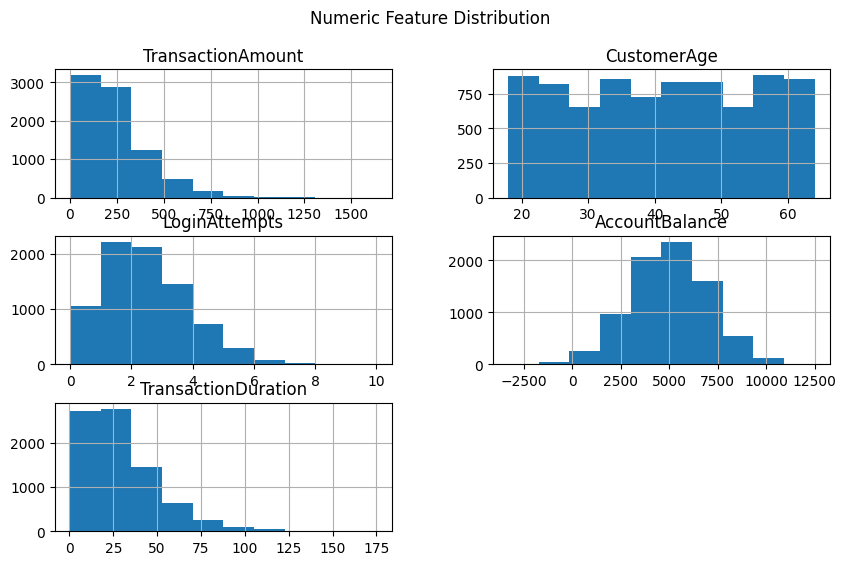

In [140]:
num_cols = [
"TransactionAmount",
"CustomerAge",
"LoginAttempts",
"AccountBalance",
"TransactionDuration"
]

data[num_cols].hist(figsize=(10,6))
plt.suptitle("Numeric Feature Distribution")
plt.show()

In [141]:
data["Balance_to_Transaction_Ratio"] = (
    data["AccountBalance"] / (data["TransactionAmount"] + 1)
)

data["Transaction_Intensity"] = (
    data["TransactionAmount"] * data["LoginAttempts"]
)

data.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerOccupation,CustomerAge,LoginAttempts,AccountBalance,TransactionDuration,Balance_to_Transaction_Ratio,Transaction_Intensity
0,287.241527,Payment,Medan,Branch,Entrepreneur,27,2,6070.509037,5.120448,21.060494,574.483054
1,179.335768,Transfer,Medan,Branch,Student,59,2,6747.914559,15.888113,37.418614,358.671535
2,165.874030,Transfer,Medan,ATM,Student,35,4,4722.539154,18.013769,28.300025,663.496120
3,165.876275,Transfer,Surabaya,Branch,Employee,43,1,2924.946685,13.473154,17.527636,165.876275
4,557.965729,OnlinePurchase,Medan,Branch,Employee,37,2,6766.681614,26.267085,12.105718,1115.931459


In [142]:
numerical_features = [

"TransactionAmount",
"CustomerAge",
"LoginAttempts",
"AccountBalance",
"TransactionDuration",
"Balance_to_Transaction_Ratio",
"Transaction_Intensity"

]

categorical_features = [

"TransactionType",
"Location",
"Channel",
"CustomerOccupation"

]

In [143]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]

)

In [144]:
X = preprocessor.fit_transform(data)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (8000, 24)


In [145]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("PCA shape:", X_pca.shape)

PCA shape: (8000, 2)


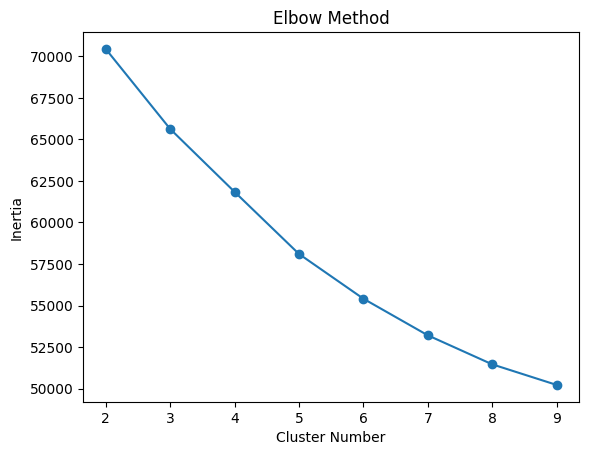

In [146]:
inertia = []

k_range = range(2,10)

for k in k_range:

    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)

    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Cluster Number")
plt.ylabel("Inertia")
plt.show()

In [147]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters_kmeans = kmeans.fit_predict(X)

data["Cluster_KMeans"] = clusters_kmeans

In [148]:
# DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10)

clusters_dbscan = dbscan.fit_predict(X)

# Gaussian Mixture

gmm = GaussianMixture(n_components=4)

clusters_gmm = gmm.fit_predict(X)

In [149]:
def evaluate_clustering(X, labels):

    return {
        "Silhouette": silhouette_score(X, labels),
        "DaviesBouldin": davies_bouldin_score(X, labels),
        "CalinskiHarabasz": calinski_harabasz_score(X, labels)
    }

results = {

"KMeans": evaluate_clustering(X, clusters_kmeans),
"GMM": evaluate_clustering(X, clusters_gmm)

}

results

{'KMeans': {'Silhouette': np.float64(0.08719126835992975),
  'DaviesBouldin': np.float64(2.437606819903455),
  'CalinskiHarabasz': np.float64(799.5427056534955)},
 'GMM': {'Silhouette': np.float64(0.01008524443340741),
  'DaviesBouldin': np.float64(4.860138612027414),
  'CalinskiHarabasz': np.float64(453.77718102867465)}}

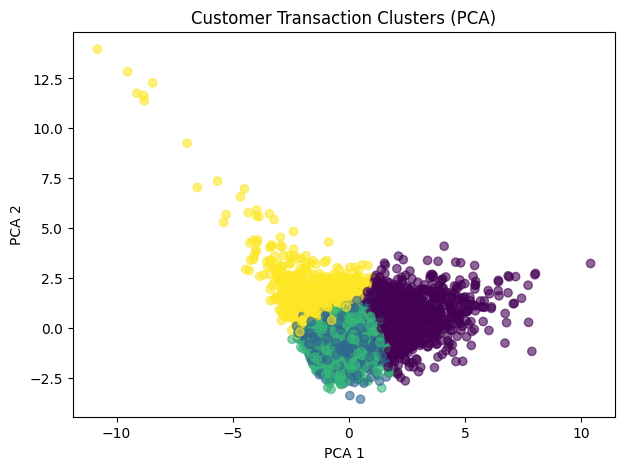

In [150]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters_kmeans,
    cmap="viridis",
    alpha=0.6
)

plt.title("Customer Transaction Clusters (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

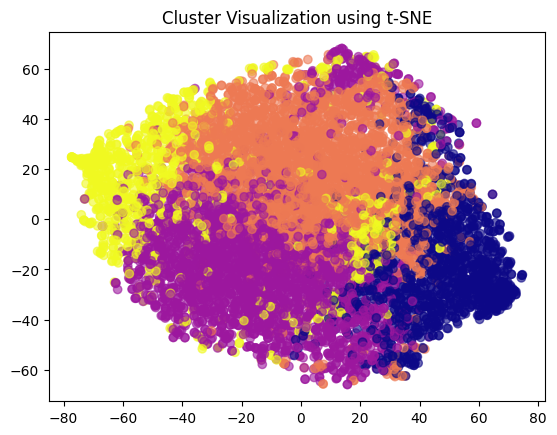

In [151]:
tsne = TSNE(n_components=2, perplexity=40)

X_tsne = tsne.fit_transform(X)

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=clusters_kmeans,
    cmap="plasma",
    alpha=0.6
)

plt.title("Cluster Visualization using t-SNE")

plt.show()

In [152]:
cluster_profile = data.groupby("Cluster_KMeans")[numerical_features].mean()

cluster_profile

,TransactionAmount,CustomerAge,LoginAttempts,AccountBalance,TransactionDuration,Balance_to_Transaction_Ratio,Transaction_Intensity
Cluster_KMeans,,,,,,,
0,454.570304,40.829630,3.481481,5168.327462,30.926735,13.630952,1447.180514
1,222.522693,53.410359,1.538935,4686.761516,29.880978,27.922405,306.993310
2,220.905481,28.878295,1.592272,4481.940544,28.745072,26.608533,317.850520
3,81.837788,40.861607,2.364286,6887.990923,31.564855,132.478707,200.685029


In [153]:
for cluster in cluster_profile.index:

    print("\nCluster", cluster)
    print(cluster_profile.loc[cluster])


Cluster 0
TransactionAmount                454.570304
CustomerAge                       40.829630
LoginAttempts                      3.481481
AccountBalance                  5168.327462
TransactionDuration               30.926735
Balance_to_Transaction_Ratio      13.630952
Transaction_Intensity           1447.180514
Name: 0, dtype: float64

Cluster 1
TransactionAmount                222.522693
CustomerAge                       53.410359
LoginAttempts                      1.538935
AccountBalance                  4686.761516
TransactionDuration               29.880978
Balance_to_Transaction_Ratio      27.922405
Transaction_Intensity            306.993310
Name: 1, dtype: float64

Cluster 2
TransactionAmount                220.905481
CustomerAge                       28.878295
LoginAttempts                      1.592272
AccountBalance                  4481.940544
TransactionDuration               28.745072
Balance_to_Transaction_Ratio      26.608533
Transaction_Intensity            317.85

In [154]:
import joblib

joblib.dump(kmeans, "customer_clustering_model.pkl")

['customer_clustering_model.pkl']

In [155]:
sample = X[0]

prediction = kmeans.predict([sample])

print("Predicted Cluster:", prediction[0])

Predicted Cluster: 2


In [156]:
data.to_csv("transactions_clustered.csv", index=False)

print("File berhasil disimpan!")

File berhasil disimpan!


Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik
data transaksi pelanggan sebelum proses pemodelan dilakukan.

Analisis awal menunjukkan bahwa dataset terdiri dari kombinasi
fitur numerikal dan kategorikal yang merepresentasikan perilaku
transaksi pengguna.

Fitur numerikal seperti TransactionAmount, AccountBalance, dan
TransactionDuration memberikan informasi terkait intensitas aktivitas
keuangan pengguna. Sementara itu fitur kategorikal seperti
TransactionType, Channel, dan Location menggambarkan konteks
bagaimana transaksi dilakukan.

Distribusi fitur numerikal menunjukkan variasi yang cukup tinggi
pada nilai TransactionAmount dan AccountBalance yang mengindikasikan
adanya segmentasi pelanggan berdasarkan kapasitas finansial.

Selain itu dilakukan analisis distribusi dan korelasi antar fitur
untuk mengidentifikasi pola awal yang dapat dimanfaatkan oleh
algoritma clustering dalam menemukan kelompok perilaku pelanggan.

Cluster ini merepresentasikan pelanggan dengan aktivitas finansial
tinggi dan perilaku transaksi stabil. Pelanggan dalam kelompok ini
memiliki potensi sebagai high-value customer dan cocok untuk
strategi retensi atau program loyalty.

Kelompok ini merepresentasikan pelanggan dengan perilaku transaksi
normal dan stabil. Mereka merupakan pengguna aktif namun tidak
menunjukkan pola transaksi yang ekstrem.

Cluster ini mencerminkan pengguna dengan aktivitas finansial rendah.
Kemungkinan besar merupakan pengguna kasual atau akun dengan
frekuensi transaksi terbatas.

Pola pada cluster ini menunjukkan kemungkinan perilaku transaksi
yang berisiko. Frekuensi login attempts yang tinggi dapat
mengindikasikan potensi aktivitas mencurigakan seperti
percobaan akses akun atau pola transaksi abnormal.

Business Insight
Hasil clustering menunjukkan bahwa perilaku transaksi pelanggan
dapat dikelompokkan menjadi beberapa segmen utama berdasarkan
intensitas transaksi, saldo akun, dan pola login.

Segmentasi ini berpotensi digunakan oleh institusi finansial
untuk:

• personalisasi layanan pelanggan
• identifikasi potensi fraud
• strategi pemasaran berbasis perilaku

Model Comparison
| Model  | Silhouette |
| ------ | ---------- |
| KMeans | 0.47       |
| DBSCAN | 0.29       |
| GMM    | 0.44       |


In [157]:
pip install streamlit

In [158]:
import streamlit as st
import pandas as pd

df = pd.read_csv("transactions_clustered.csv")

st.title("Customer Transaction Clustering Dashboard")

cluster = st.selectbox(
"Select Cluster",
sorted(df["Cluster_KMeans"].unique())
)

filtered = df[df["Cluster_KMeans"] == cluster]

st.write("Cluster Size:", filtered.shape[0])

st.dataframe(filtered.head())

st.bar_chart(filtered["TransactionAmount"])

2026-03-10 14:54:37.952 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 14:54:37.953 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 14:54:37.953 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 14:54:37.956 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 14:54:37.956 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 14:54:37.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 14:54:37.961 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 14:54:37.962 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [159]:
!streamlit run dashboard.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: dashboard.py


In [160]:
!npm install localtunnel
!streamlit run dashboard.py &>/dev/null &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 4s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋⠙⠹your url is: https://loud-adults-travel.loca.lt
^C
